## Position of a star

### Part 1
Likelihood, MLE estimator 


In [4]:
import numpy as np 
import matplotlib.pyplot as plt 
import random
from random import sample
import scipy.stats 
from astroML.datasets import fetch_dr7_quasar  

In some cases (for example N=5 and random seed(2)) the Likelihood is much less than the other distributions. But it is just a case, in N increases it doesn't happen 


They are single individual likelihoods: the probability of collecting the data I have collected given the parameters 

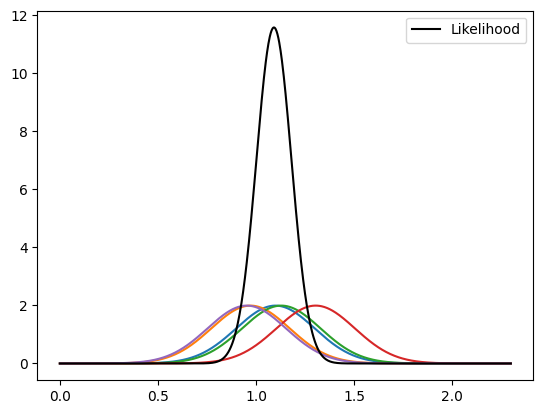

In [ ]:
N=5      #number of measurements 

#the underlying process is Gaussian
mu=1
sigma=0.2

np.random.seed(42)
gauss = scipy.stats.norm(loc=mu,scale=sigma)
sample=gauss.rvs(N)                                 #N samples drawn from the Gaussian distribution

x_plot=np.linspace(0,2.3,1000)

L=1

for i in sample:
    distrib=scipy.stats.norm(i,sigma)               #different gaussian centered in the measurements
    plt.plot(x_plot,distrib.pdf(x_plot))
    L*=distrib.pdf(x_plot)


plt.plot(x_plot,L, label="Likelihood", color='black')
plt.legend()
plt.show()


In [98]:
max_like=max(L) #maximum likelihood
max_index=np.where(L==max_like) #index of maximum 
max_L=x_plot[max_index] #x of maximum 


print("%0.4f" % np.mean(sample), "is the MLE for mu")
print("%0.4f" % max_L[0], "is the max of likelihood (computed numerically)")

1.0918 is the MLE for mu
1.0913 is the max of likelihood (computed numerically)


### Part 2
Uncertainties of MLE, second order differentiation

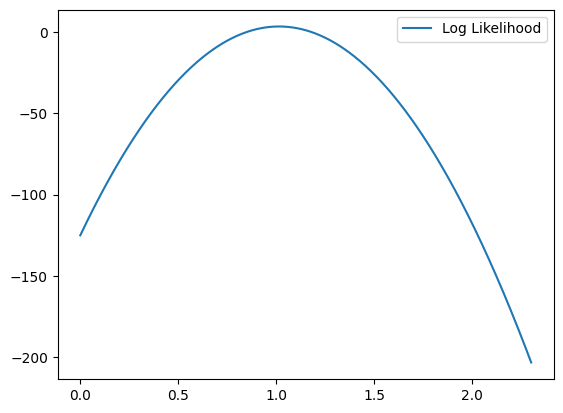

0.06324555320337495179 is MLE for sigma
0.06324555320336758268 is the theoretical error for mu


In [ ]:

l=np.log(L) #log of likelihood 
plt.plot(x_plot,l, label="Log Likelihood")
plt.legend()
plt.show()

d1=np.diff(l)/np.diff(x_plot) #first derivative: ratio between small increments on x and y 

# plt.plot(x_plot[0:len(d1)],d1, label='First derivative of logL') #the length of d1 is one less than the length of the x 
# plt.legend()
# plt.show()

d2=np.diff(d1)/np.diff(x_plot[0:len(d1)]) #second derivative

# plt.plot(x_plot[0:len(d2)],d2, label='Second derivative of logL')
# plt.legend() #at the extrema is quite noisy 
# plt.show()


sigma_mu=(-d2[max_index])**(-0.5) #result of the Fischer matrix

err_mu_th=sigma/np.sqrt(N)

print("%0.20f" % sigma_mu[0], "is MLE for sigma")
print("%0.20f" % err_mu_th, "is the theoretical error for mu") 
#the difference appears after several decimal places

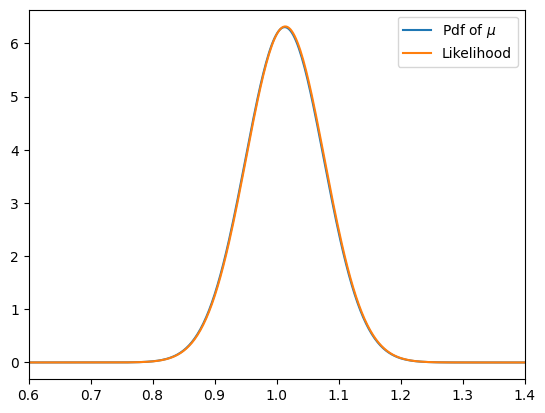

In [110]:
plt.plot(x_plot, norm.pdf(x_plot, max_L[0], sigma_mu), label=r"Pdf of $\mu$")
plt.plot(x_plot,L/5.13, label="Likelihood")
plt.xlim(0.6,1.4)
plt.legend()
plt.show()

I think the reason is that the product of gaussians (the Likelihood) is still a gaussian with same $\mu$ but $\sigma_{product}=\sigma/\sqrt{N}$. Indeed the product of $N$ gaussians is:

$$G= \bigg( \frac{1}{\sqrt{2\pi}\sigma}\bigg)^N \exp\bigg(- \frac{(x-\mu)^2}{2(\frac{\sigma}{\sqrt{N}} )^2}\bigg) $$
